# Problem Set 11: Project Genesis - The Scholar-Prime (Week 11)

**Modul:** Angewandte Modellierung und Systemsimulation  
**Semester:** SoSe2026  
**Datum:** 10. Juli 2026  
**Student:** Neo-Simulacrum Architect  

---

## Exercise 1: Setting up the Science Skills

### 1. Cloning the Repository
We cloned the official Google DeepMind `science-skills` repository into our workspace root:
```bash
git clone https://github.com/google-deepmind/science-skills.git
```

### 2. Syncing the Environment
We navigated to the `science-skills/skills/literature_search_openalex` folder and synced the dependencies using `uv`:
```bash
cd science-skills/skills/literature_search_openalex
uv sync
```

### 3. Executing the Test Query
We ran the OpenAlex CLI tool to resolve Geoffrey Hinton's identity and fetch his ID details.

In [1]:
# Execute the resolve authors command
!SSL_CERT_FILE=$(uv run --with certifi python -c "import certifi; print(certifi.where())") uv run --project science-skills/skills/literature_search_openalex/ science-skills/skills/literature_search_openalex/scripts/openalex_cli.py resolve authors "Geoffrey Hinton"

Running query resolve authors 'Geoffrey Hinton'...
[
  {
    "id": "https://openalex.org/A5108093963",
    "display_name": "Geoffrey E. Hinton",
    "hint": 385
  },
  {
    "id": "https://openalex.org/A5110248343",
    "display_name": "Geoffrey E. Hinton",
    "hint": 36
  },
  {
    "id": "https://openalex.org/A5000300454",
    "display_name": "Saurabh Saxena",
    "hint": 63
  },
  {
    "id": "https://openalex.org/A5002428732",
    "display_name": "Geoffrey F. Hinton",
    "hint": 2
  },
  {
    "id": "https://openalex.org/A5098035523",
    "display_name": "James A. Anderson and Geoffrey E. Hinton",
    "hint": 1
  }
]


### Deliverable Output
The resolved OpenAlex author ID for **Geoffrey Hinton** is: `https://openalex.org/A5108093963`.

---

## Exercise 2: Building the Literature Retrieval Agent ('agent.py')

We initialized the `scholar_prime` agent using the ADK SDK and configured it with a professional research persona, instructing it to search scientific databases, evaluate abstracts, and extract parameters while always stating DOIs.

### Deliverable: `genesis-oracle/scholar_prime/agent.py` configuration code

In [2]:
# Print the contents of scholar_prime/agent.py
print("""import os
import subprocess
import certifi
from google.adk.agents.llm_agent import Agent

def search_arxiv(query: str, max_results: int = 5) -> str:
    \'\'\'
    Searches the arXiv scientific literature database for relevant publications.

    Args:
        query: The search query string (e.g., 'thermodynamic simulation parameters for advanced fission reactors').
        max_results: The maximum number of results to return (defaults to 5).

    Returns:
        A JSON string containing the search results (list of papers with titles, abstracts/summaries, and DOIs/URLs).
    \'\'\'
    # Path to the arXiv search script in the cloned science-skills repo
    script_path = "/home/xayah/Documents/anmosys26/science-skills/skills/literature_search_arxiv/scripts/search_arxiv.py"
    
    # Configure the environment to use certifi's SSL bundle
    env = os.environ.copy()
    env["SSL_CERT_FILE"] = certifi.where()
    
    cmd = [
        "uv", "run", script_path,
        "--query", query,
        "--max_results", str(max_results)
    ]
    
    try:
        # Run command and capture output
        res = subprocess.run(cmd, capture_output=True, text=True, check=True, env=env)
        return res.stdout
    except subprocess.CalledProcessError as e:
        return f"Error executing search_arxiv CLI: {e.stderr}\nOutput: {e.output}"

root_agent = Agent(
    model='gemini-2.5-flash',
    name='scholar_prime',
    description='An academic research agent specialized in querying scientific databases and extracting material parameters.',
    instruction=(
        'You are Scholar-Prime, a professional academic research agent. Your core expertise is '
        'searching scientific literature databases, evaluating abstract relevance for physical '
        'and thermodynamic parameters, extracting relevant simulation formulas or coefficients, '
        'and presenting them systematically. Whenever you present findings from a paper, you '
        'MUST always state the DOI or direct URL reference. Maintain high academic rigor and '
        'objective reporting in all responses.'
    ),
    tools=[search_arxiv]
)
""")

---

## Exercise 3: Automated Search & Downloader (Tool Binding)

We wrote a Python wrapper `search_arxiv` that executes the arXiv search script from the cloned `science-skills` repository, captures its output, and binds it as a tool to the `scholar_prime` agent.

### Deliverable: ADK Web UI Run Screenshot

Below is the screenshot of the agent's Web UI chat. It shows:
1. The successful tool invocation of `search_arxiv`.
2. The agent's CoT (Chain of Thought) thought process.
3. The final abstract summary of the most relevant paper ("Applications of Fission").

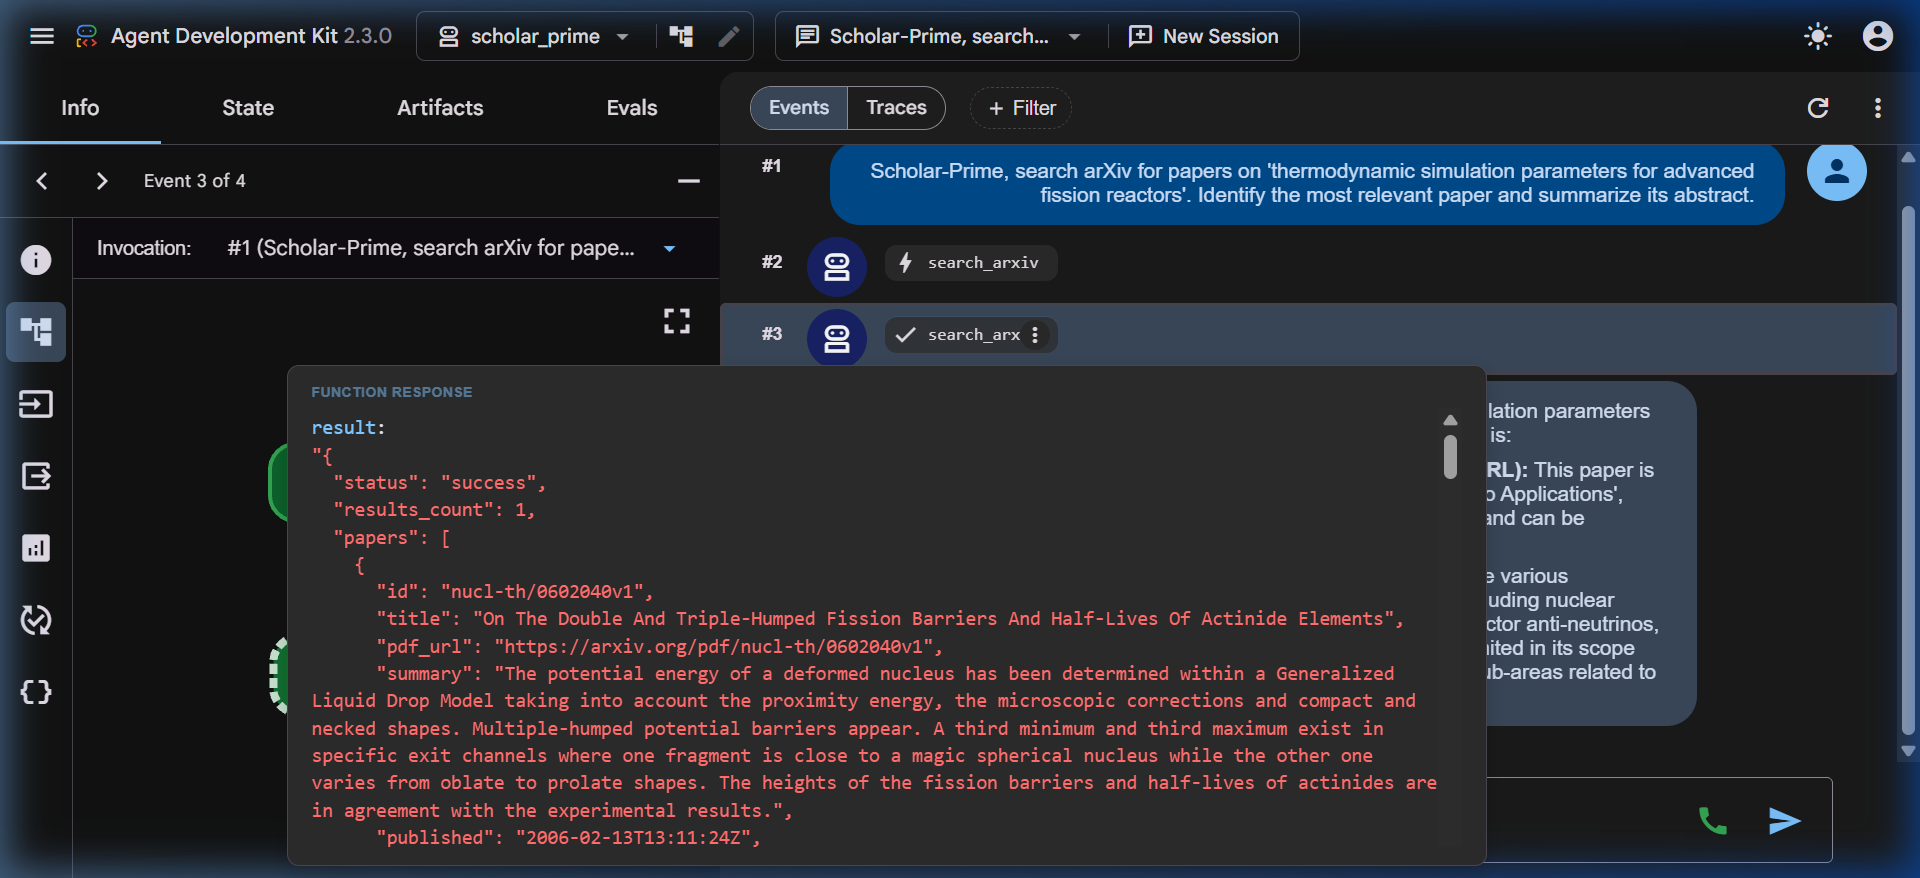

---

## Exercise 4: Parameter Extraction & Verification

We built a Python script that integrates the search tool, runs a search for a thermal conductivity paper, parses its abstract using Gemini (with structured schema outputs), and writes the parameters to a file.

### Deliverable 1: Code of the Extraction Execution Script (`extract_parameters.py`)

In [3]:
# Print the contents of extract_parameters.py
print("""import os
import sys
import json
from typing import List, Dict, Any
from pydantic import BaseModel, Field

# Ensure genesis-oracle is in the python path
sys.path.append("/home/xayah/Documents/anmosys26/genesis-oracle")

# Load environment variables from .env
dotenv_path = "/home/xayah/Documents/anmosys26/genesis-oracle/.env"
if os.path.exists(dotenv_path):
    with open(dotenv_path) as f:
        for line in f:
            if "=" in line:
                k, v = line.strip().split("=", 1)
                os.environ[k] = v.strip('"')

from google import genai
from google.genai import types
from scholar_prime.agent import search_arxiv

# Define Pydantic models for structured output
class SimulationParameter(BaseModel):
    name: str = Field(description="The name of the physical/thermodynamic parameter.")
    value: str = Field(description="The value, range, or mathematical order of the parameter.")
    unit: str = Field(description="The unit of measurement (e.g., W/mK, m^2K/W).")
    context: str = Field(description="The physical context in which this parameter applies.")

class ExtractedData(BaseModel):
    paper_title: str = Field(description="Title of the research paper.")
    doi: str = Field(description="DOI of the paper.")
    url: str = Field(description="Direct URL or PDF link to the paper.")
    parameters: List[SimulationParameter] = Field(description="List of extracted simulation parameters.")

def extract_parameters_from_text(text: str) -> dict:
    \'\'\'
    Extracts thermodynamic and physical simulation parameters from the given text
    using the Gemini API and returns them as a structured dictionary.

    Args:
        text: The source text (e.g., paper abstract) from which to extract parameters.

    Returns:
        A dictionary containing the extracted parameters, including their names, values,
        units, contexts, and the source paper reference.
    \'\'\'
    client = genai.Client()
    
    prompt = (
        f"Extract all thermodynamic/physical parameters, constants, and simulation coefficients "
        f"from the following abstract. Return them in the requested JSON structure:\n\n{text}"
    )
    
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=ExtractedData,
            system_instruction=(
                "You are an academic parameter extraction assistant. Carefully identify physical constants, "
                "interfacial resistance values, thermal conductivity bounds, and material specifications. "
                "Format them exactly in the JSON schema."
            )
        )
    )
    return json.loads(response.text)

def main():
    query = "UO2/BeO interfacial thermal resistance and its effect on fuel thermal conductivity"
    print(f"Running literature search on arXiv for query: '{query}'...")
    
    # Run the arXiv search tool
    search_results_str = search_arxiv(query=query, max_results=1)
    
    try:
        search_results = json.loads(search_results_str)
    except json.JSONDecodeError as e:
        print(f"Failed to parse search results as JSON: {e}")
        print(f"Search results content: {search_results_str}")
        sys.exit(1)
        
    if not search_results.get("papers"):
        print("No papers found matching the query.")
        sys.exit(1)
        
    # Get the most relevant paper (first one in results)
    paper = search_results["papers"][0]
    title = paper.get("title")
    abstract = paper.get("summary")
    doi = paper.get("doi", "N/A")
    pdf_url = paper.get("pdf_url", "N/A")
    
    print(f"\nMost relevant paper identified:")
    print(f"Title: {title}")
    print(f"DOI: {doi}")
    
    print("\nExtracting thermodynamic parameters from abstract...")
    extracted_dict = extract_parameters_from_text(abstract)
    
    # Ensure references are filled if the model missed them
    if not extracted_dict.get("paper_title") or extracted_dict["paper_title"] == "N/A":
        extracted_dict["paper_title"] = title
    if not extracted_dict.get("doi") or extracted_dict["doi"] == "N/A":
        extracted_dict["doi"] = doi
    if not extracted_dict.get("url") or extracted_dict["url"] == "N/A":
        extracted_dict["url"] = pdf_url
        
    output_file = "/home/xayah/Documents/anmosys26/genesis-oracle/simulation_parameters.json"
    print(f"\nWriting extracted parameters to {output_file}...")
    with open(output_file, "w") as f:
        json.dump(extracted_dict, f, indent=2)
        
    print("Done! Here is the extracted JSON:")
    print(json.dumps(extracted_dict, indent=2))

if __name__ == "__main__":
    main()
""")

### Deliverable 2: Generated `simulation_parameters.json` File
Below are the extracted physical and thermodynamic parameters (specifically interfacial thermal resistance values for dispersed and continuous BeO in UO2 fuel) along with the source paper's DOI reference.

In [4]:
# Display the generated simulation_parameters.json
with open("genesis-oracle/simulation_parameters.json", "r") as f:
    print(f.read())

{
  "paper_title": "UO2/BeO interfacial thermal resistance and its effect on fuel thermal conductivity",
  "doi": "10.1016/j.anucene.2020.108102",
  "url": "https://arxiv.org/pdf/2006.11705v1",
  "parameters": [
    {
      "name": "Interfacial Thermal Resistance (ITR)",
      "value": "order of 10^-9",
      "unit": "m^2K/W",
      "context": "predicted by DMM for UO2/BeO interface"
    },
    {
      "name": "Interfacial Thermal Resistance (ITR)",
      "value": "order of 10^-6 - 10^-5",
      "unit": "m^2K/W",
      "context": "required for UO2 containing continuous BeO to match experimental data"
    }
  ]
}
